In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

In [2]:
n_requests = 5000

users = [f"user_{i}" for i in range(300)]
query_types = ["support", "finance", "hr", "engineering", "sales"]

start_date = datetime(2025, 1, 1)

data = []

for i in range(n_requests):
    user = random.choice(users)
    qtype = random.choice(query_types)

    latency = abs(np.random.normal(1.2, 0.5))  # seconds
    retrieval_score = np.clip(np.random.normal(0.75, 0.15), 0, 1)

    # simulate degradation
    drift_factor = np.random.rand()
    if drift_factor > 0.97:
        retrieval_score *= 0.5  # bad retrieval event

    error_flag = 1 if np.random.rand() < 0.03 else 0

    timestamp = start_date + timedelta(minutes=i*2)

    data.append([
        user,
        qtype,
        timestamp,
        round(latency, 3),
        round(retrieval_score, 3),
        error_flag
    ])

df = pd.DataFrame(data, columns=[
    "user_id",
    "query_type",
    "timestamp",
    "latency_sec",
    "retrieval_score",
    "error_flag"
])

df.head()

,user_id,query_type,timestamp,latency_sec,retrieval_score,error_flag
0,user_57,support,2025-01-01 00:00:00,1.448,0.729,0
1,user_140,finance,2025-01-01 00:02:00,1.083,0.715,0
2,user_114,finance,2025-01-01 00:04:00,1.990,0.865,0
3,user_52,sales,2025-01-01 00:06:00,0.965,0.831,0
4,user_44,sales,2025-01-01 00:08:00,1.321,0.463,0


In [3]:
kpis = {
    "avg_latency": df["latency_sec"].mean(),
    "p95_latency": np.percentile(df["latency_sec"], 95),
    "avg_retrieval_score": df["retrieval_score"].mean(),
    "error_rate": df["error_flag"].mean()
}

kpis

{'avg_latency': np.float64(1.2144944),
 'p95_latency': np.float64(2.038),
 'avg_retrieval_score': np.float64(0.7401466),
 'error_rate': np.float64(0.032)}

In [4]:
sla = df.groupby("query_type").agg({
    "latency_sec": "mean",
    "retrieval_score": "mean",
    "error_flag": "mean"
}).reset_index()

sla.columns = ["query_type", "avg_latency", "avg_retrieval_score", "error_rate"]

sla.sort_values("error_rate", ascending=False)

,query_type,avg_latency,avg_retrieval_score,error_rate
1,finance,1.217297,0.739238,0.035928
3,sales,1.197099,0.733339,0.032686
4,support,1.221409,0.735550,0.031683
0,engineering,1.209628,0.744263,0.030710
2,hr,1.227223,0.748346,0.028956


In [5]:
df["rolling_score"] = df["retrieval_score"].rolling(window=50).mean()

df["degradation_flag"] = np.where(
    df["rolling_score"] < 0.6,
    1,
    0
)

df["degradation_flag"].value_counts()

,count
degradation_flag,
0,5000


In [6]:
lat_mean = df["latency_sec"].mean()
lat_std = df["latency_sec"].std()

df["latency_anomaly"] = np.where(
    df["latency_sec"] > lat_mean + 3 * lat_std,
    1,
    0
)

df["latency_anomaly"].sum()

np.int64(4)

In [7]:
df["health_score"] = (
    0.4 * df["retrieval_score"] +
    0.3 * (1 - df["latency_sec"] / df["latency_sec"].max()) +
    0.3 * (1 - df["error_flag"])
)

system_health = df["health_score"].mean()
system_health

np.float64(0.7582572606896552)

In [8]:
trend = df.set_index("timestamp").resample("D").agg({
    "retrieval_score": "mean",
    "latency_sec": "mean",
    "error_flag": "mean"
}).reset_index()

trend.head()

,timestamp,retrieval_score,latency_sec,error_flag
0,2025-01-01,0.747765,1.206986,0.037500
1,2025-01-02,0.736842,1.208574,0.031944
2,2025-01-03,0.732974,1.197981,0.031944
3,2025-01-04,0.747647,1.226596,0.034722
4,2025-01-05,0.734468,1.216238,0.027778


In [9]:
df.to_csv("rag_logs.csv", index=False)
sla.to_csv("rag_sla_metrics.csv", index=False)
trend.to_csv("rag_trend_analysis.csv", index=False)

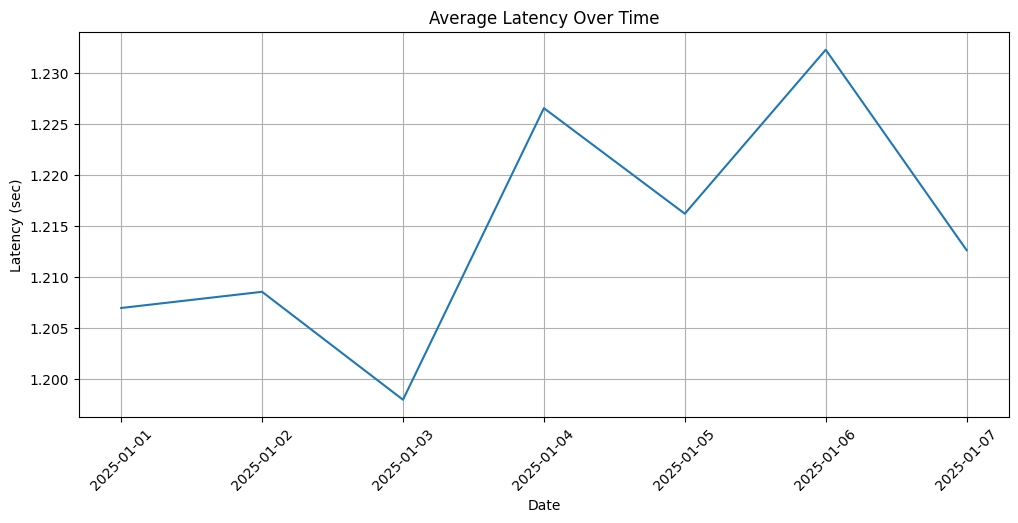

In [10]:
import matplotlib.pyplot as plt

trend_daily = df.set_index("timestamp").resample("D")["latency_sec"].mean()

plt.figure(figsize=(12,5))
plt.plot(trend_daily.index, trend_daily.values)
plt.title("Average Latency Over Time")
plt.xlabel("Date")
plt.ylabel("Latency (sec)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

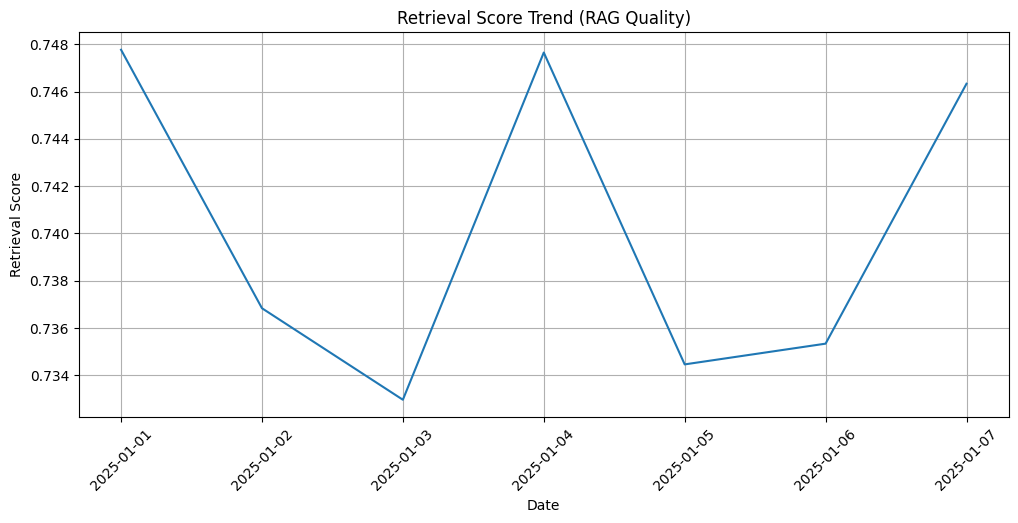

In [11]:
trend_retrieval = df.set_index("timestamp").resample("D")["retrieval_score"].mean()

plt.figure(figsize=(12,5))
plt.plot(trend_retrieval.index, trend_retrieval.values)
plt.title("Retrieval Score Trend (RAG Quality)")
plt.xlabel("Date")
plt.ylabel("Retrieval Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

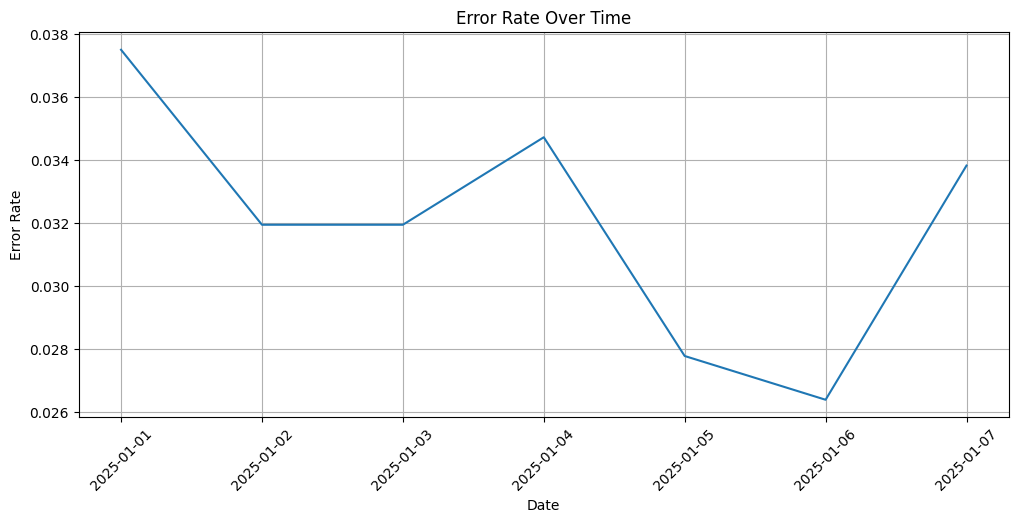

In [12]:
error_trend = df.set_index("timestamp").resample("D")["error_flag"].mean()

plt.figure(figsize=(12,5))
plt.plot(error_trend.index, error_trend.values)
plt.title("Error Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.grid()
plt.show()

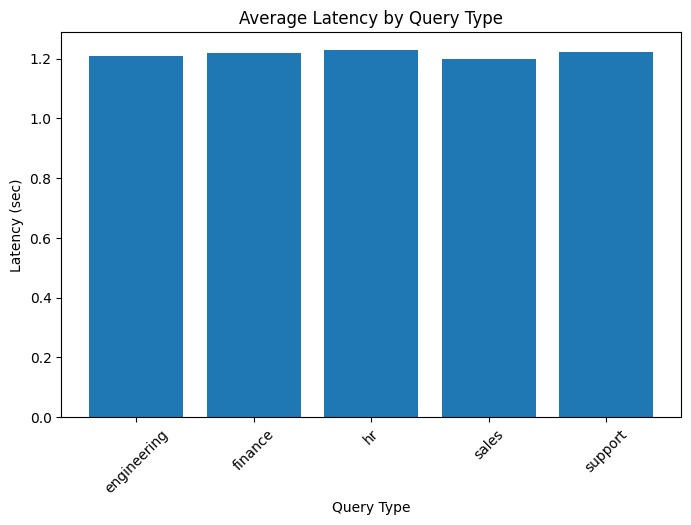

In [13]:
plt.figure(figsize=(8,5))
plt.bar(sla["query_type"], sla["avg_latency"])
plt.title("Average Latency by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Latency (sec)")
plt.xticks(rotation=45)
plt.show()

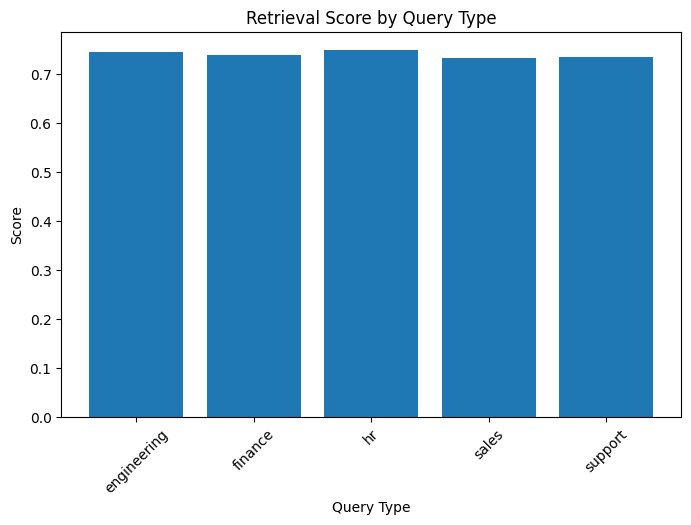

In [14]:
plt.figure(figsize=(8,5))
plt.bar(sla["query_type"], sla["avg_retrieval_score"])
plt.title("Retrieval Score by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

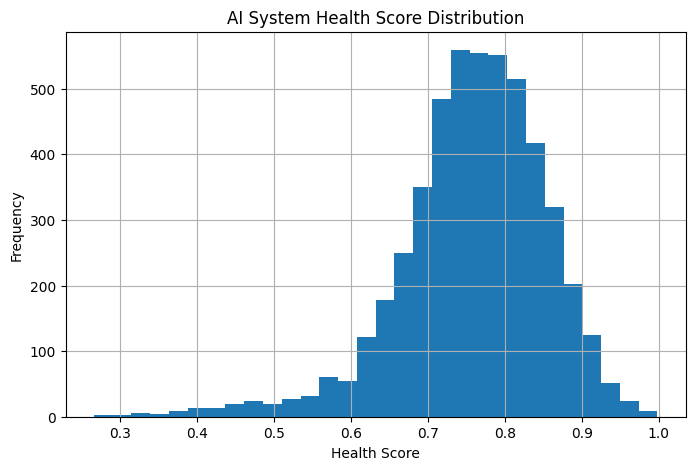

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["health_score"], bins=30)
plt.title("AI System Health Score Distribution")
plt.xlabel("Health Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()

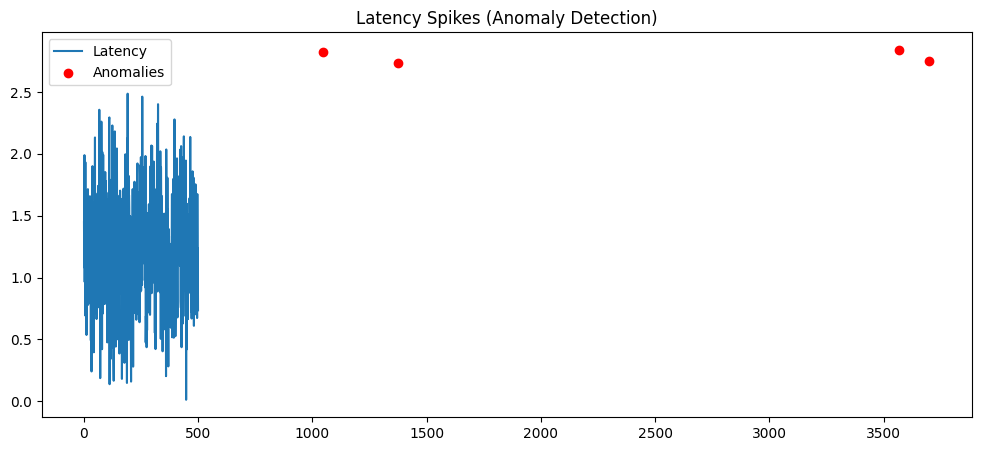

In [16]:
anomalies = df[df["latency_anomaly"] == 1]

plt.figure(figsize=(12,5))
plt.plot(df["latency_sec"].values[:500], label="Latency")
plt.scatter(anomalies.index[:50], anomalies["latency_sec"][:50], color="red", label="Anomalies")
plt.title("Latency Spikes (Anomaly Detection)")
plt.legend()
plt.show()